In [1]:
import numpy as np
import random as rn
import matplotlib.pyplot as pl

In [ ]:
cid = np.array([0,1,2,3,4,5,6,7,8,9])

# Task A

In [ ]:
def MakeMatrix(n):
    # define the matrix A, with siz n x n
    A = np.zeros((n,n))
    # fill matrix A
    for i in range(n):
        A[i,i] = i + 1
        A[i,-1-i] = n - i
    return A

In [ ]:
A = MakeMatrix(10)
for row in A:
    print(row)

In [ ]:
# determine the Minor of a square matrix, by excluding the i-th row and the j-th column
def Minor(A,i,j):
    N = A.shape[0] # size of the square matrix A
    # create a matrix of smaller dimensions (N-1,N-1)
    M = np.zeros((N-1,N-1))
    M[:i,:j] = A[:i,:j]  # assign the NW quadrant
    M[:i,j:] = A[:i,j+1:] # assign the NE quadrant
    M[i:,:j] = A[i+1:,:j]  # assign the SW quadrant
    M[i:,j:] = A[i+1:,j+1:] # assign the SE quadrant
    return M

# calculate the determinant of a square matrix
def Determinant(A):   # size of the square matrix A
    N = A.shape[0]
    if N == 2: # smallest possible matrix: the determinant is, by definition A[0,0]*A[1,1] - A[1,0]*A[0,1]
        det = A[0,0]*A[1,1] - A[1,0]*A[0,1]
    else:
        # apply the formula
        det = 0
        for k in range(N):
            det += (-1)**(0+k)*A[0,k]*Determinant(Minor(A,0,k))
    return det

In [ ]:
def Series(N):
    S = 0
    for i in range(2,N+1):
        S += Determinant(MakeMatrix(i))
    return S

In [ ]:
S = np.zeros(len(cid))
for i in range(len(cid)):
    S[i] = Series(i)
pl.scatter(cid,S)

# Task B

In [ ]:
f = open('ME1.txt','r')
tmp = f.readlines()
f.close()

In [ ]:
Ns = 100
ME1 = []
c = 0
for i in range(Ns):
    name = tmp[c].rstrip()
    c += 1
    nex = int(tmp[c])
    c += 1
    marks = []
    for j in range(nex):
        marks += [int(tmp[c])]
        c += 1
    ME1 += [(name,nex,marks)]

for stud in ME1:
    print(stud)

In [ ]:
# determine average mark for each student
average = []
for i in range(Ns):
    s = 0
    nex = ME1[i][1]
    for j in range(nex):
        s += ME1[i][2][j]
    average += [s/nex]

for i in range(Ns):
    print(ME1[i][0],average[i])

In [ ]:
# sort students in descending order, by their average mark
for i in range(Ns):
    for k in range(i+1,Ns):
        if average[i] < average[k]:
            # swap student i with student j in ME1
            (average[i],average[k]) = (average[k],average[i]) 
            (ME1[i],ME1[k]) = (ME1[k],ME1[i])
            
for i in range(Ns):
    print(ME1[i][0],average[i])

In [ ]:
# find the highest mark
highest = 0
for i in range(Ns):
    nex = ME1[i][1]
    for j in range(nex):
        mark =  ME1[i][2][j]
        if mark > highest:
            highest = mark
# now set a list of students who have achieved at least one instance of teh highest mark
listh = []
for i in range(Ns):
    nex = ME1[i][1]
    for j in range(nex):
        mark =  ME1[i][2][j]
        if mark == highest:
            listh += [ME1[i][0]]

print(listh)

In [ ]:
# count how many students have achieved each numerical mark
occ = []
marks = []
# scroll all the numerical marks
for value in range(1,101):
    marks += [value]
    # examine how many times mark value has been assigned
    s = 0
    # scroll all the students and all the marks
    for i in range(Ns):
        nex = ME1[i][1]
        for j in range(nex):
            mark =  ME1[i][2][j] 
            if mark == value:
                s += 1
    occ += [s]
    
pl.bar(marks,occ)
pl.grid()

# Task C

In [ ]:
def Squares(n,l):
    if n == 1:
        pl.plot([0,l,l,0,0],[0,0,l,l,0],c='blue')
    else:
        pl.plot([0,l,l,0,0],[0,0,l,l,0],c='red')
        Squares(n-1,l/1.1)
        
    pl.axis("equal")
    return


Squares(10,10)

# Task D

In [ ]:
c = 0
cs = 0
level = int(input("Insert a crime: "))
while level != 0:
    if level >= 7 and level <= 20:
        # consider this level
        c += 1
        if level > 16:
            cs += 1
    # read next crime
    level = int(input("Insert a crime: "))
    
    
print(c,cs)
        

# Task E

Insert the initial angle (in degrees) :25
21


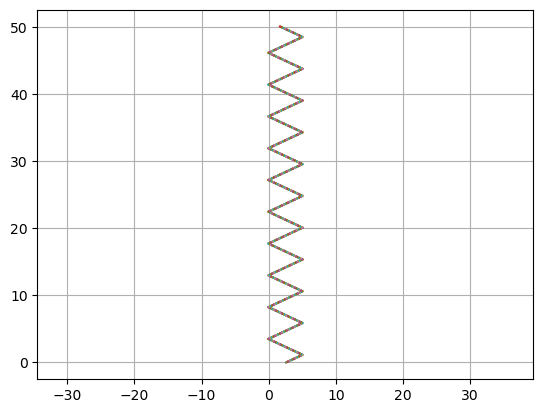

In [2]:
d = 0.1
maxx = 5
maxy = 50
# set the initial position of the ball
x0 = rn.random()*maxx
# set the initial angle
theta = int(input("Insert the initial angle (in degrees) :")) * np.pi/180

# move the ball
# determine the incremental motion
(dx,dy) = (d*np.cos(theta),d*np.sin(theta))
# set the initial position
(x,y) = (x0,0)
bounces = 0
while y < maxy:
    # move by (dx,dy)
    (x,y) = (x+dx,y+dy)
    pl.plot([x-dx,x],[y-dy,y])
    pl.axis([0,maxx,0,maxy])
    pl.axis("equal")
    # assess if the ball has reached one of the vertical walls and needs to revert direction
    if x <= 0 or x >= maxx:
        # revert motion
        (dx,dy) = (-dx,dy)
        bounces += 1

pl.grid()
print(bounces)